In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline

import inversion_tools

#start_date = '2016-01-01'
#end_date   = '2016-06-01'
start_date = '2014-09-01'
end_date   = '2022-01-01'
pdir  = '/work/noaa/co2/jhollo/processed_transport_data/'

In [2]:
# ------------ read control emissions data for ocean, gpp, resp
args  = {'start_date':start_date, 'end_date':end_date, 'processing_dir':pdir, 'return_mf':False, 'quiet':True}
ocean_flx = inversion_tools.read_transport_jacobians_control('ocean', **args)

reading data for splits [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
---------- split 1 ----------
reading flux data at the surface...
took 2.17 s
done
---------- split 2 ----------
reading flux data at the surface...
took 1.83 s
done
---------- split 3 ----------
reading flux data at the surface...
took 1.81 s
done
---------- split 4 ----------
reading flux data at the surface...
took 1.96 s
done
---------- split 5 ----------
reading flux data at the surface...
took 1.96 s
done
---------- split 6 ----------
reading flux data at the surface...
took 1.95 s
done
---------- split 7 ----------
reading flux data at the surface...
took 1.92 s
done
---------- split 8 ----------
reading flux data at the surface...
took 2.15 s
done
---------- split 9 ----------
reading flux data at the surface...
took 2.30 s
done
---------- split 10 ----------
reading flux data at the surface...
took 2.17 s
done
---------- split 11 ----------
reading flux data at the surface...
took 1.89 

In [12]:
# ------------ read residual emissions data for ocean from region 14, gpp and resp from region 3
args  = {'start_date':start_date, 'end_date':end_date, 'month':'2016-01', 'processing_dir':pdir, 'return_flux':False, 'quiet':True}
ocean_mf_r17 = inversion_tools.read_transport_jacobians_residual('ocean', region=17, **args)
ocean_mf_r19 = inversion_tools.read_transport_jacobians_residual('ocean', region=19, **args)

reading data for splits [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
---------- split 1 ----------
reading mole fraction data for all vertical levels...
took 9.49 s
done
---------- split 2 ----------
reading mole fraction data for all vertical levels...
took 9.50 s
done
---------- split 3 ----------
reading mole fraction data for all vertical levels...
took 9.01 s
done
---------- split 4 ----------
reading mole fraction data for all vertical levels...
took 9.84 s
done
---------- split 5 ----------
reading mole fraction data for all vertical levels...
took 2.86 s
done
---------- split 6 ----------
reading mole fraction data for all vertical levels...
took 10.12 s
done
---------- split 7 ----------
reading mole fraction data for all vertical levels...
took 9.55 s
done
---------- split 8 ----------
reading mole fraction data for all vertical levels...
took 14.22 s
done
---------- split 9 ----------
reading mole fraction data for all vertical levels...
took 15.92 s
done
---------- split 10 ---

In [14]:
# ------------ get time series averaged on the Nino-3.4 region
weighted_lat_avg = lambda data: data.weighted(np.cos(np.deg2rad(data.lat))).mean('lat')
lon_avg          = lambda data: data.mean('lon')
horz_avg         = lambda data: lon_avg(weighted_lat_avg(data))
nino_region      = {'lat':slice(-5, 5), 'lon':slice(-170, -120)}
amazon_region    = {'lat':slice(-15, 15), 'lon':slice(-80, -45)}
n_atl_region     = {'lat':slice(20, 45), 'lon':slice(-60, -20)}
s_atl_region     = {'lat':slice(-45, -20), 'lon':slice(-35, 10)}

ocean_flx_nino   = horz_avg(ocean_flx.sel(nino_region))

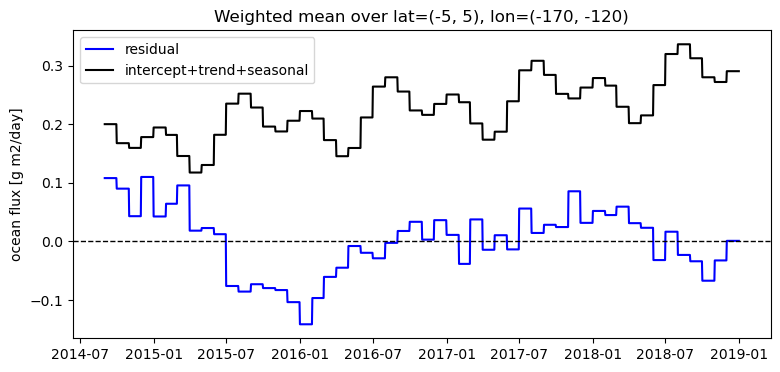

In [134]:
# ------------ plot time series for fluxes
net_flux = lambda data: data['intercept'] + data['trend'] + data['sin1'] + data['sin2'] + data['cos1'] + data['cos2'] + data['residual']

def plot_flux_timeseries(x, y, r, label, title, color='r', twinx=False, yfrac=0):
    fig = plt.figure(figsize=(9,4))
    ax  = fig.add_subplot()
    if(twinx): ax2 = ax.twinx()
    else:      ax2 = ax
    ax.plot(x, r, '-', color=color, label='residual')
    ax2.plot(x, y-r, '-k', label='intercept+trend+seasonal')
    if(twinx):
        ax.plot(x[0], r[0], '-k', label='intercept+trend+seasonal')
    ylim = ax.get_ylim()
    ypad = abs(ylim[0]-ylim[1]) * yfrac
    ylim2 = ax2.get_ylim()
    ypad2 = abs(ylim[0]-ylim[1]) * yfrac
    ax.set_ylim([ylim[0] - ypad, ylim[1] + ypad])
    ax2.set_ylim([ylim2[0] - ypad2, ylim2[1] + ypad2])
    ax.set_ylabel(f'{label} flux [g m2/day]')
    ax2.set_ylabel(f'{label} flux [g m2/day]')
    ax.legend()
    ax.set_title(title)
    ax.axhline(y=0, ls='--', color='k', lw=1)

# ---- ocean
y = net_flux(ocean_flx_nino)
r = ocean_flx_nino['residual']
x = y.time
plot_flux_timeseries(x, y, r, 'ocean', 'Weighted mean over lat=(-5, 5), lon=(-170, -120)', 'b')
plt.savefig('ocean_flux_timeseries_nin34.png', dpi=200)

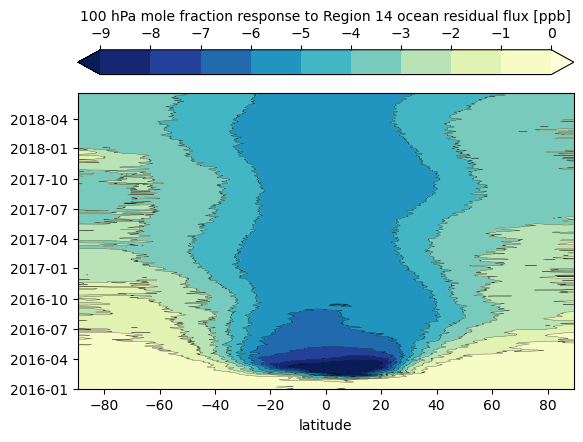

In [133]:
# ------------ plot zonal-mean time series for mf at select pressure levels

# ---- ocean
dd = ocean_mf_r14['residual'].mean('lon').isel(lev=35).isel(time=slice(0, 900))
levels = [-9, -8, -7, -6, -5, -4, -3, -2, -1, 0]
fig = plt.figure()
ax = fig.add_subplot()
cf = ax.contourf(dd.lat, dd.time, dd*1e3, levels=levels, extend='both', cmap='YlGnBu_r')
ax.contour(dd.lat, dd.time, dd*1e3, levels=levels, colors='k', linestyles='-', linewidths=0.2)
ax.set_xlabel('latitude')
cb = plt.colorbar(cf, location='top')
cb.set_label('100 hPa mole fraction response to Region 14 ocean residual flux [ppb]')
plt.savefig('lat_time_100hPa.png', dpi=200)

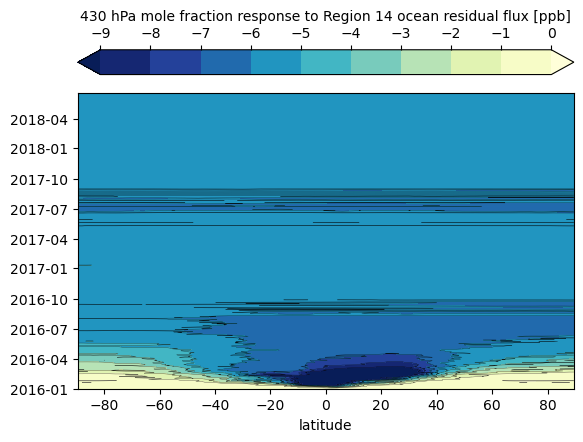

In [17]:
# ------------ plot zonal-mean time series for mf at select pressure levels

# ---- ocean
dd = ocean_mf_r14['residual'].mean('lon').isel(lev=25).isel(time=slice(0, 900))
levels = [-9, -8, -7, -6, -5, -4, -3, -2, -1, 0]
fig = plt.figure()
ax = fig.add_subplot()
cf = ax.contourf(dd.lat, dd.time, dd*1e3, levels=levels, extend='both', cmap='YlGnBu_r')
ax.contour(dd.lat, dd.time, dd*1e3, levels=levels, colors='k', linestyles='-', linewidths=0.2)
ax.set_xlabel('latitude')
cb = plt.colorbar(cf, location='top')
cb.set_label('430 hPa mole fraction response to Region 14 ocean residual flux [ppb]')

In [21]:
# ------------ get column-integrated tracers
out = f'{pdir}/column_averages/ocean_XCO2_region14_{start_date}_{end_date}.nc'
ocean_xco2_r14 = inversion_tools.column_average(ocean_mf_r14['residual'], outfile=out)

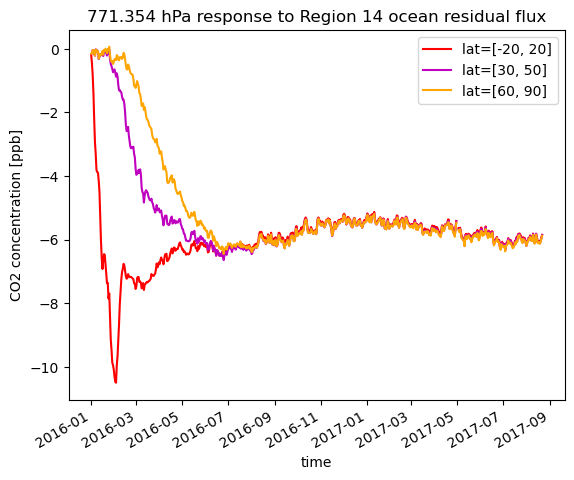

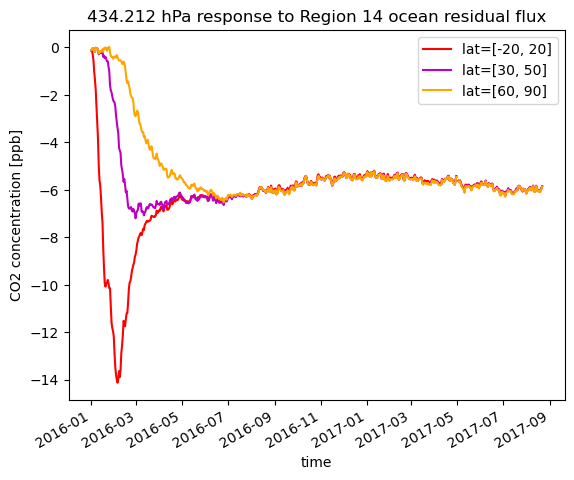

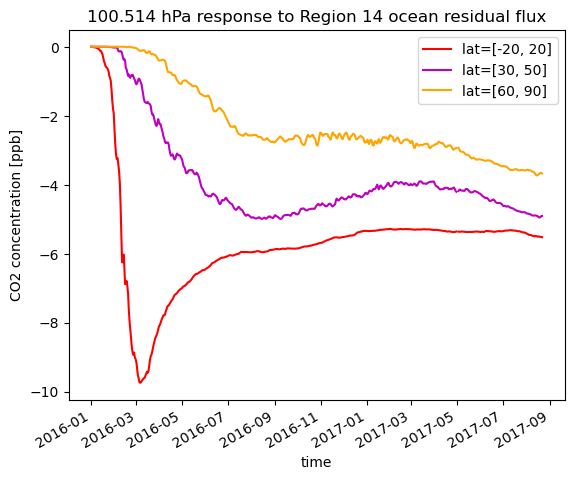

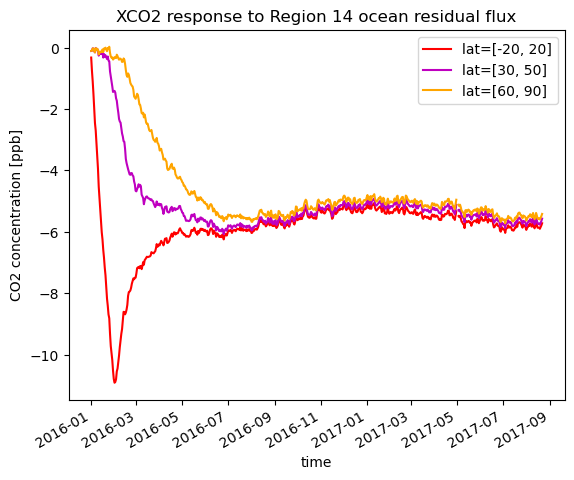

In [144]:
# ------------ plot zonal-mean time series for mf at select pressure levels, and select latitudes

def plot_curves(time, data_trop, data_midlat, data_hilat, label):
    fig = plt.figure()
    ax = fig.add_subplot()
    ax.plot(time, data_trop*1e3, '-r', label='lat=[-20, 20]')
    ax.plot(time, data_midlat*1e3, '-m', label='lat=[30, 50]')
    ax.plot(time, data_hilat*1e3, '-', color='orange', label='lat=[60, 90]')
    ax.set_xlabel('time')
    ax.set_ylabel('CO2 concentration [ppb]')
    ax.set_title(f'{label} response to Region 14 ocean residual flux')
    ax.legend()
    for label in ax.get_xmajorticklabels() + ax.get_xmajorticklabels():
        label.set_rotation(30)
        label.set_horizontalalignment("right")

for lev in [35, 25, 15][::-1]:

    pp = inversion_tools.lev_to_p(lev)
    
    # ---- ocean
    dd = ocean_mf_r14['residual'].isel(lev=lev).isel(time=slice(0, 600))
    dd_trop   = horz_avg(dd.sel(lat=slice(-20, 20)))
    dd_midlat = horz_avg(dd.sel(lat=slice(30, 50)))
    dd_hilat  = horz_avg(dd.sel(lat=slice(60, 90)))

    plot_curves(dd.time, dd_trop, dd_midlat, dd_hilat, f'{pp} hPa')
    plt.savefig(f'co2_vtime_{pp}hPa.png', dpi=200)

dd        = ocean_xco2_r14.isel(time=slice(0, 600))
dd_trop   = horz_avg(dd.sel(lat=slice(-20, 20)))
dd_midlat = horz_avg(dd.sel(lat=slice(30, 50)))
dd_hilat  = horz_avg(dd.sel(lat=slice(60, 90)))
plot_curves(dd.time, dd_trop, dd_midlat, dd_hilat, 'XCO2')
plt.savefig('xco2_vtime.png', dpi=200)

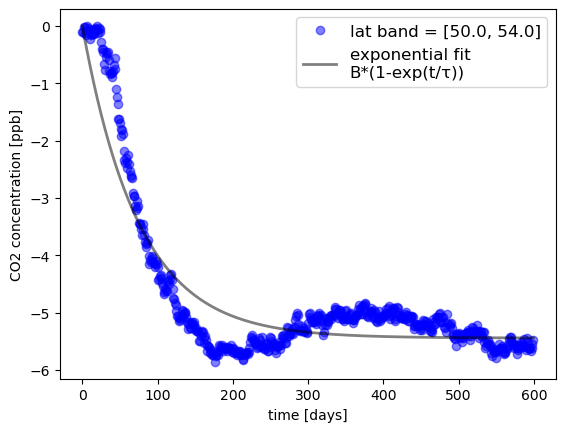

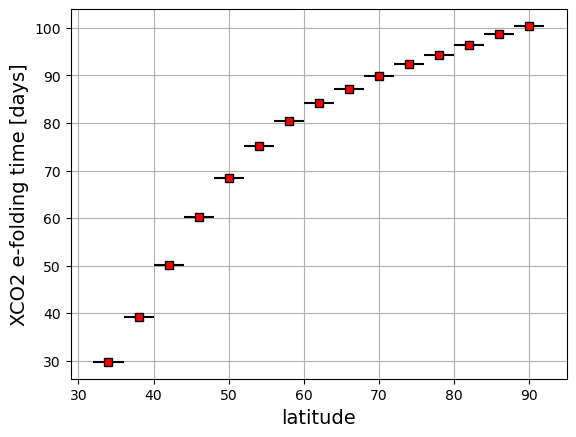

In [141]:
from scipy.optimize import curve_fit
import pdb

lat_bins    = 15
minlat      = 30
bin_edges   = np.linspace(minlat, 90, lat_bins+1)
bin_centers = np.cumsum(np.diff(bin_edges)) + bin_edges[0]
bin_widths  = np.diff(bin_edges)
tau         = np.zeros(lat_bins)

data = ocean_xco2_r14.isel(time=slice(0, 600)) * 1e3

fig = plt.figure()
ax  = fig.add_subplot(111)
ax.set_ylabel('CO2 concentration [ppb]')
ax.set_xlabel('time [days]')

for i in range(lat_bins):
    print(f'---- {i+1}/{lat_bins} ----', end='\r')
    lats = slice(bin_edges[i], bin_edges[i+1])

    dd = horz_avg(data.sel(lat=lats))
    dd = dd.dropna('time')
    dd = dd.where(np.isfinite(dd), drop=True)
    tt = dd.time
    # seconds since first timestamp
    tt = (tt - tt[0]) / np.timedelta64(1, "D")
    
    def model(x, B, T):
        return B * (1 - np.exp(-(1/T) * x))

    popt, pcov = curve_fit(model, tt, dd)
    B, taui = popt

    if(i == 5):
        ax.plot(tt, dd, 'ob', alpha=0.5, label=f'lat band = [{bin_edges[i]}, {bin_edges[i+1]}]')
        ax.plot(tt, model(tt, B, taui), '-k', alpha=0.5, lw=2, label='exponential fit\nB*(1-exp(t/τ))')
        
    tau[i] = taui
ax.legend(fontsize=12)
plt.savefig('taufit_lat50-54.png', dpi=200)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.errorbar(bin_centers, tau, marker='s', color='k', markerfacecolor='r', xerr=bin_widths/2, linestyle='none')
ax.set_xlabel('latitude', fontsize=14)
ax.set_ylabel('XCO2 e-folding time [days]', fontsize=14)
ax.grid()
plt.savefig('tau_xco2.png', dpi=200)

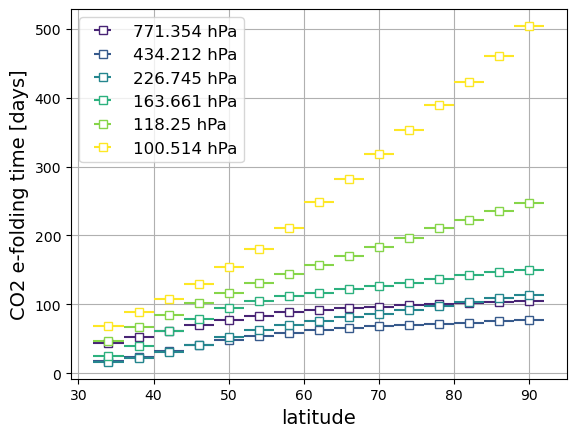

In [129]:
from scipy.optimize import curve_fit
import pdb

lat_bins    = 15
minlat      = 30
bin_edges   = np.linspace(minlat, 90, lat_bins+1)
bin_centers = np.cumsum(np.diff(bin_edges)) + bin_edges[0]
bin_widths  = np.diff(bin_edges)
tau         = np.zeros(lat_bins)
ppp = np.linspace(15, 35, 5).astype(int)
ppp = [15, 25, 30, 32, 34, 35]

colors = plt.cm.viridis(np.linspace(0.1, 1, len(ppp)))

data = ocean_mf_r14['residual'].isel(time=slice(0, 600)) * 1e3

fig = plt.figure()
ax = fig.add_subplot(111)

for j in range(len(ppp)):

    for i in range(lat_bins):
        print(f'---- {i+1}/{lat_bins} ----', end='\r')
        lats = slice(bin_edges[i], bin_edges[i+1])

        dd = data.isel(lev = ppp[j])
        dd = horz_avg(dd.sel(lat=lats))
        dd = dd.dropna('time')
        dd = dd.where(np.isfinite(dd), drop=True)
        tt = dd.time
        # seconds since first timestamp
        tt = (tt - tt[0]) / np.timedelta64(1, "D")
        
        def model(x, B, T):
            return B * (1 - np.exp(-(1/T) * x))
    
        popt, pcov = curve_fit(model, tt, dd)
        B, taui = popt
        tau[i] = taui
        
    ax.errorbar(bin_centers, tau, marker='s', color=colors[j], markerfacecolor='w', xerr=bin_widths/2, linestyle='none', label=f'{inversion_tools.lev_to_p(ppp[j])} hPa')
     
ax.set_xlabel('latitude', fontsize=14)
ax.set_ylabel('CO2 e-folding time [days]', fontsize=14)
ax.grid()
ax.legend(fontsize=12)
plt.savefig('tau_co2.png', dpi=200)